In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [9]:
df = pd.read_csv("spam_email.csv", sep='\t', names=['label','message'])
df.head(8)

print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns)

print("\nNull values:\n", df.isnull().sum())

print("\nFirst 5 rows:\n", df.head())

Shape of dataset: (5572, 2)

Columns: Index(['label', 'message'], dtype='object')

Null values:
 label      0
message    0
dtype: int64

First 5 rows:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [10]:
# Convert labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

# Apply cleaning
df['message'] = df['message'].apply(clean_text)
print(df)

      label                                            message
0         0  jurong point crazy available bugis n great wor...
1         0                            ok lar joking wif u oni
2         1  free entry 2 wkly comp win fa cup final tkts 2...
3         0                        u dun say early hor u c say
4         0                      nah dont think goes usf lives
...     ...                                                ...
5567      1  2nd time tried 2 contact u u won 750 pound pri...
5568      0                          b going esplanade fr home
5569      0                        pity mood soany suggestions
5570      0  guy did bitching acted like id interested buyi...
5571      0                                          rofl true

[5572 rows x 2 columns]


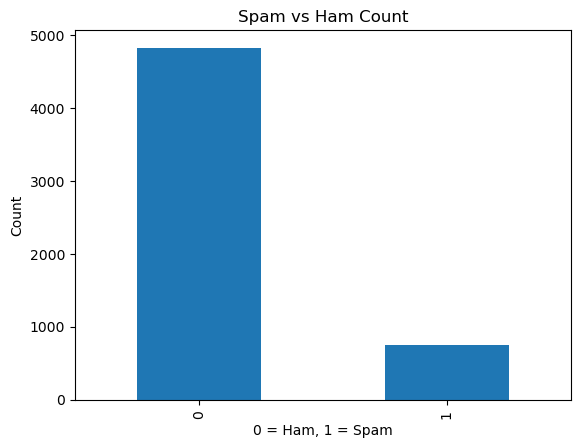

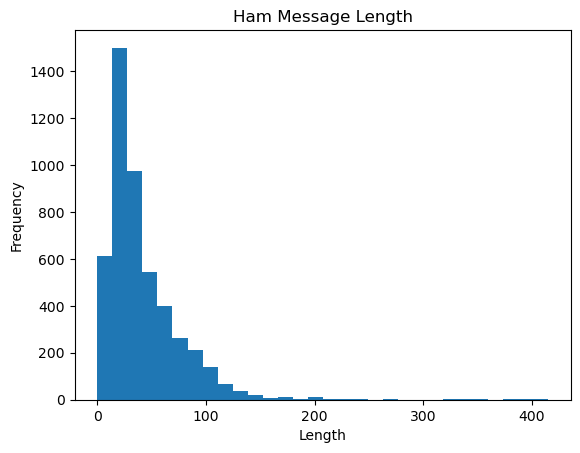

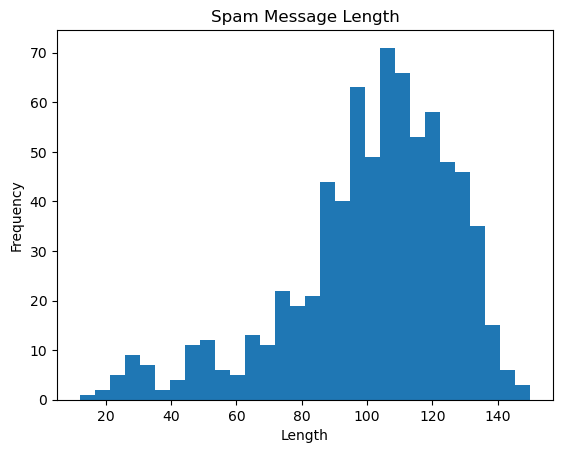

In [11]:
# ================= SPAM vs HAM COUNT =================
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Count")
plt.xlabel("0 = Ham, 1 = Spam")
plt.ylabel("Count")
plt.show()

# ================= MESSAGE LENGTH =================
df['length'] = df['message'].apply(len)

# Ham messages
plt.hist(df[df['label']==0]['length'], bins=30)
plt.title("Ham Message Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# Spam messages
plt.hist(df[df['label']==1]['length'], bins=30)
plt.title("Spam Message Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [13]:
X = df['message']
y = df['label']

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

X_tfidf = tfidf.fit_transform(X)
print(X_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 39504 stored elements and shape (5572, 3000)>
  Coords	Values
  (0, 1996)	0.3409868983984732
  (0, 664)	0.33761965834845503
  (0, 327)	0.3315109932261376
  (0, 450)	0.3682992953627737
  (0, 1102)	0.24264830193991666
  (0, 2923)	0.30064033591853595
  (0, 1436)	0.3682992953627737
  (0, 558)	0.3682992953627737
  (0, 1087)	0.2045915489421472
  (0, 2812)	0.2485713941290362
  (1, 1856)	0.241665272749865
  (1, 1447)	0.3599893616786887
  (1, 1378)	0.46168858179843136
  (1, 2869)	0.38053445212672243
  (1, 1874)	0.48191642911699
  (1, 1860)	0.4709557250459977
  (2, 975)	0.1254802741212803
  (2, 871)	0.38957215681852175
  (2, 2895)	0.20620239002929933
  (2, 606)	0.21285389878123503
  (2, 2874)	0.16071339068846288
  (2, 900)	0.5083536909476122
  (2, 679)	0.218288577146526
  (2, 941)	0.1991560648413507
  (2, 2580)	0.23895005049281154
  :	:
  (5567, 445)	0.22057091207648064
  (5567, 102)	0.2280331076387256
  (5567, 2571)	0.224068204500138